In [1]:
pip install scipy numpy matplotlib pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\celin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [3]:
# Sanity check — if this runs without error, you're set up correctly
from scipy.stats import norm
print("scipy.stats works! norm mean:", norm.mean())  # should print 0.0

scipy.stats works! norm mean: 0.0


In [4]:
# 1. Create a range of x values to plot
# --------------------------------------------------
x = np.linspace(-4, 4, 300)  
# linspace makes 300 evenly-spaced points from -4 to 4

In [5]:
# 2. Calculate PDF values (the height of the curve)
# --------------------------------------------------
pdf_values = norm.pdf(x)   # using standard normal (mean=0, std=1)


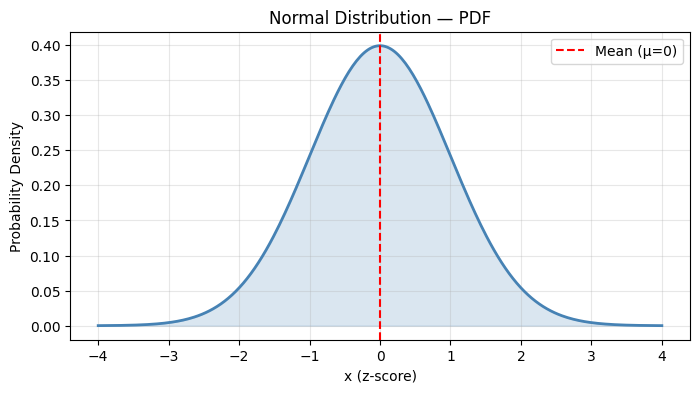

In [6]:
# 3. Plot it
# --------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(x, pdf_values, color='steelblue', linewidth=2)
plt.fill_between(x, pdf_values, alpha=0.2, color='steelblue')
plt.title("Normal Distribution — PDF")
plt.xlabel("x (z-score)")
plt.ylabel("Probability Density")
plt.axvline(0, color='red', linestyle='--', label='Mean (μ=0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

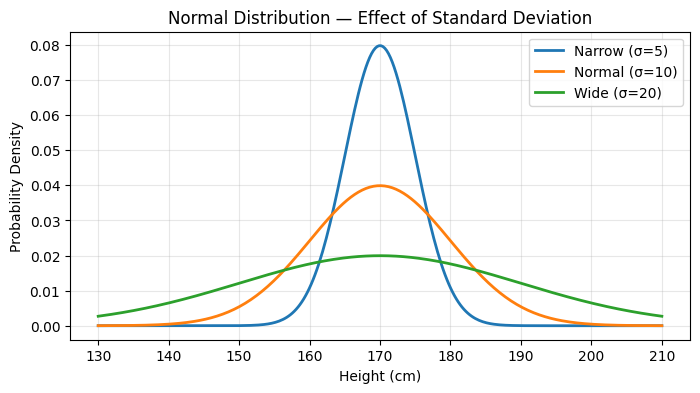

In [7]:
# 4. Try changing the parameters
# --------------------------------------------------
x2 = np.linspace(130, 210, 300)  # range for heights

plt.figure(figsize=(8, 4))
for mean, std, label in [(170, 5, 'Narrow (σ=5)'), 
                          (170, 10, 'Normal (σ=10)'), 
                          (170, 20, 'Wide (σ=20)')]:
    plt.plot(x2, norm.pdf(x2, loc=mean, scale=std), label=label, linewidth=2)

plt.title("Normal Distribution — Effect of Standard Deviation")
plt.xlabel("Height (cm)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

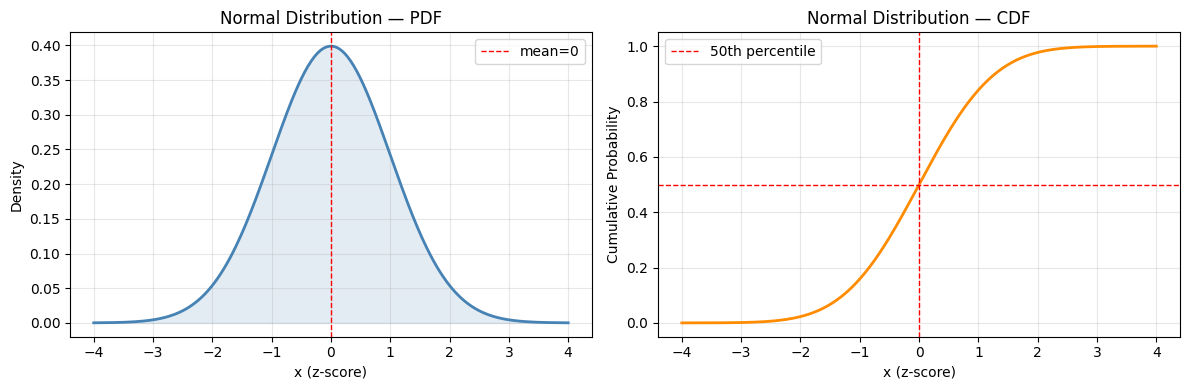

The z-score at the 95th percentile is: 1.6449


In [8]:
x = np.linspace(-4, 4, 300)

pdf_vals = norm.pdf(x)   # height of the curve
cdf_vals = norm.cdf(x)   # cumulative area from -infinity to x

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left plot: PDF ---
axes[0].plot(x, pdf_vals, color='steelblue', linewidth=2)
axes[0].fill_between(x, pdf_vals, alpha=0.15, color='steelblue')
axes[0].set_title("Normal Distribution — PDF")
axes[0].set_xlabel("x (z-score)")
axes[0].set_ylabel("Density")
axes[0].axvline(0, color='red', linestyle='--', linewidth=1, label='mean=0')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Right plot: CDF ---
axes[1].plot(x, cdf_vals, color='darkorange', linewidth=2)
axes[1].set_title("Normal Distribution — CDF")
axes[1].set_xlabel("x (z-score)")
axes[1].set_ylabel("Cumulative Probability")
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1, label='50th percentile')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Now use .ppf() to find the 95th percentile z-score ---
z_95 = norm.ppf(0.95)
print(f"The z-score at the 95th percentile is: {z_95:.4f}")

In [10]:
print(norm.pdf(-1))   # height at x=-1       → ~0.2420  (a density, not a %)
print(norm.cdf(-1))   # area left of x=-1    → ~0.1587  (a real probability: ~15.87%)

0.24197072451914337
0.15865525393145707


In [11]:
print(norm.cdf(0))

0.5


### Lesson 2: Discrete distributions

In [ ]:
from scipy.stats import binom

# n — number of trials (e.g. 10 coin flips)
# p — probability of success on each trial (e.g. 0.5 for a fair coin)

dist = binom(n=10, p=0.5)

In [ ]:
from scipy.stats import poisson

#mu — the average rate (e.g. 8 calls per hour)

dist = poisson(mu=8)

In [14]:
from scipy.stats import binom, poisson

# --- Binomial: 10 coin flips, p=0.5 ---
b = binom(n=10, p=0.5)

print(b.pmf(6))      # P(exactly 6 heads)       → 0.2051
print(b.cdf(6))      # P(6 or fewer heads)       → 0.8281
print(b.ppf(0.95))   # smallest k where CDF≥0.95 → 8.0
print(b.rvs(10))     # 10 random samples         → e.g. [5,4,6,5,7,4,6,5,5,6]

# --- Poisson: avg 4 events per hour ---
p = poisson(mu=4)

print(p.pmf(6))      # P(exactly 6 events)       → 0.1042
print(p.cdf(6))      # P(6 or fewer events)       → 0.8893
print(p.ppf(0.95))   # 95th percentile count      → 7.0
print(p.rvs(10))     # 10 random samples

0.2050781249999999
0.828125
8.0
[8 5 5 2 9 6 2 7 7 5]
0.10419563456702102
0.8893260215974264
8.0
[3 5 4 6 3 3 4 4 5 3]


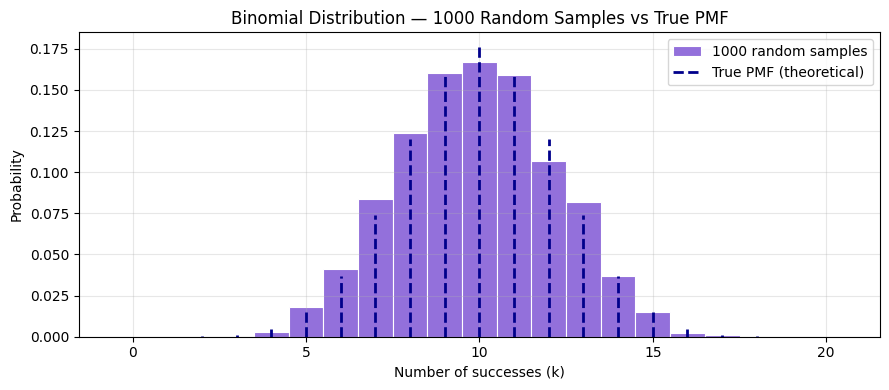

Sample mean:     9.929  (theoretical: 10.0)
Sample std dev:  2.244  (theoretical: 2.236)
Most common value: 10


In [17]:
import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt

# --- Generate 1000 random samples ---
# n=20 trials, p=0.5 probability of success each trial
samples = binom.rvs(n=20, p=0.5, size=1000, random_state=42)

# --- Plot histogram ---
fig, ax = plt.subplots(figsize=(9, 4))

# bins at each integer so each bar = one value of k
k_values = np.arange(0, 21)
ax.hist(samples, bins=np.arange(-0.5, 21.5, 1),
        color='mediumpurple', edgecolor='white', linewidth=0.8,
        density=True, label='1000 random samples')

# Overlay the true PMF so we can see how well the samples match
ax.vlines(k_values, 0, binom.pmf(k_values, n=20, p=0.5),
          colors='darkblue', linewidth=2, linestyle='--',
          label='True PMF (theoretical)')

ax.set_title("Binomial Distribution — 1000 Random Samples vs True PMF")
ax.set_xlabel("Number of successes (k)")
ax.set_ylabel("Probability")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- A few useful summaries ---
print(f"Sample mean:     {samples.mean():.3f}  (theoretical: {20 * 0.5})")
print(f"Sample std dev:  {samples.std():.3f}  (theoretical: {(20 * 0.5 * 0.5)**0.5:.3f})")
print(f"Most common value: {np.bincount(samples).argmax()}")

### phase 1 final verification

In [18]:
from scipy.stats import norm, binom, poisson
import numpy as np

print("=" * 50)
print("NORMAL DISTRIBUTION (continuous)")
print("=" * 50)
n = norm(loc=0, scale=1)
print(f".pdf(1.0)  = {n.pdf(1.0):.4f}  ← density at x=1, NOT a probability")
print(f".cdf(1.0)  = {n.cdf(1.0):.4f}  ← P(X < 1.0) = 84.13%")
print(f".ppf(0.84) = {n.ppf(0.84):.4f}  ← x where 84% lies below")
print(f".rvs(5)    = {np.round(n.rvs(5, random_state=1), 3)}")

print()
print("=" * 50)
print("BINOMIAL DISTRIBUTION (discrete)")
print("=" * 50)
b = binom(n=10, p=0.3)
print(f".pmf(3)    = {b.pmf(3):.4f}  ← P(exactly 3 successes)")
print(f".cdf(3)    = {b.cdf(3):.4f}  ← P(3 or fewer successes)")
print(f".ppf(0.90) = {b.ppf(0.90):.4f}  ← smallest k where CDF >= 90%")
print(f".rvs(5)    = {b.rvs(5, random_state=1)}")

print()
print("=" * 50)
print("POISSON DISTRIBUTION (discrete)")
print("=" * 50)
p = poisson(mu=6)
print(f".pmf(6)    = {p.pmf(6):.4f}  ← P(exactly 6 events)")
print(f".cdf(6)    = {p.cdf(6):.4f}  ← P(6 or fewer events)")
print(f".ppf(0.90) = {p.ppf(0.90):.4f}  ← 90th percentile count")
print(f".rvs(5)    = {p.rvs(5, random_state=1)}")

NORMAL DISTRIBUTION (continuous)
.pdf(1.0)  = 0.2420  ← density at x=1, NOT a probability
.cdf(1.0)  = 0.8413  ← P(X < 1.0) = 84.13%
.ppf(0.84) = 0.9945  ← x where 84% lies below
.rvs(5)    = [ 1.624 -0.612 -0.528 -1.073  0.865]

BINOMIAL DISTRIBUTION (discrete)
.pmf(3)    = 0.2668  ← P(exactly 3 successes)
.cdf(3)    = 0.6496  ← P(3 or fewer successes)
.ppf(0.90) = 5.0000  ← smallest k where CDF >= 90%
.rvs(5)    = [3 4 0 2 1]

POISSON DISTRIBUTION (discrete)
.pmf(6)    = 0.1606  ← P(exactly 6 events)
.cdf(6)    = 0.6063  ← P(6 or fewer events)
.ppf(0.90) = 9.0000  ← 90th percentile count
.rvs(5)    = [2 3 7 7 4]


In [ ]:

print(f".ppf(0.90) = {norm.ppf(0.90):.4f}  ← 90th percentile count")

.ppf(0.99) = 1.2816  ← 90th percentile count


In [23]:

print(f".ppf(0.90) = {norm.cdf(1.2816):.4f}  ← 90th percentile count")

.ppf(0.90) = 0.9000  ← 90th percentile count


In [25]:
b = binom(n=40, p=0.05)
print(f".pmf(2)    = {b.pmf(2):.4f}  ← P(exactly 2 successes)")
print(f".cdf(2)    = {b.cdf(2):.4f}  ← P(2 or fewer successes)")

.pmf(2)    = 0.2777  ← P(exactly 2 successes)
.cdf(2)    = 0.6767  ← P(2 or fewer successes)


In [28]:
# to get the probability of more than 5 occurring
# do 1 - probability of less than 5 occurring
p = poisson(mu=3)
print(f".cdf(5)    = {p.cdf(5):.4f}  ← P(5 or fewer events)")

.cdf(5)    = 0.9161  ← P(5 or fewer events)


In [29]:
a= 1-0.9161
print(a)

0.08389999999999997
